# H1: fitting f_N vs N -- combined dataset

Careful analysis tied to two specific results, combined:
- `frozen_fraction_production_20260912T074229Z` (N=100..102400, 11 points)
- `frozen_fraction_fitting_range_20260912T102036Z` (N=10,000..300,000, 20 points)

31 points total, N=100..300,000. Combining these gives leverage on the
a/N^alpha correction shape from the small-N production points (where the
correction is largest relative to noise) plus tight precision on f_inf
from the dense large-N fitting_range points.

Same two models as the earlier fits, both fit by weighted least squares
using the per-N standard errors (sigma_N = SE):

- **Model 1 (constant):** f(N) = f_inf  (1 parameter)
- **Model 2 (power-law correction):** f(N) = f_inf + a / N^alpha  (3 parameters)

chi^2 = sum( ((f_N - model(N)) / sigma_N)^2 ), reduced chi^2 = chi^2 / dof,
dof = (number of points) - (number of parameters).

Presented as-is -- no claim here about which model is "correct".

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

RUN_DIRS = [
    Path('../../data/raw/frozen_fraction_production_20260912T074229Z'),
    Path('../../data/raw/frozen_fraction_fitting_range_20260912T102036Z'),
]

summary = []
for run_dir in RUN_DIRS:
    with open(run_dir / 'summary.json') as f:
        summary.extend(json.load(f))
summary = sorted(summary, key=lambda row: row['L'])

assert len(set(row['L'] for row in summary)) == len(summary), 'duplicate N across datasets'

N = np.array([row['L'] for row in summary], dtype=float)
f = np.array([row['frozen_fraction_mean'] for row in summary])
se = np.array([row['frozen_fraction_se'] for row in summary])

print(f'{len(N)} combined points, N={int(N.min())}..{int(N.max())}')
for n_i, f_i, se_i in zip(N, f, se):
    print(f"N={int(n_i):6d}  f_N={f_i:.4f} +- {se_i:.4f}")

31 combined points, N=100..300000
N=   100  f_N=0.3490 +- 0.0035
N=   200  f_N=0.3523 +- 0.0035
N=   400  f_N=0.3567 +- 0.0034
N=   800  f_N=0.3640 +- 0.0036
N=  1600  f_N=0.3638 +- 0.0034
N=  3200  f_N=0.3603 +- 0.0032
N=  6400  f_N=0.3605 +- 0.0036
N= 10000  f_N=0.3602 +- 0.0029
N= 12800  f_N=0.3621 +- 0.0033
N= 25264  f_N=0.3577 +- 0.0015
N= 25600  f_N=0.3615 +- 0.0016
N= 40526  f_N=0.3610 +- 0.0013
N= 51200  f_N=0.3606 +- 0.0013
N= 55790  f_N=0.3601 +- 0.0013
N= 71054  f_N=0.3598 +- 0.0010
N= 86316  f_N=0.3612 +- 0.0011
N=101580  f_N=0.3591 +- 0.0010
N=102400  f_N=0.3580 +- 0.0010
N=116842  f_N=0.3595 +- 0.0007
N=132106  f_N=0.3590 +- 0.0006
N=147368  f_N=0.3595 +- 0.0006
N=162632  f_N=0.3618 +- 0.0006
N=177896  f_N=0.3598 +- 0.0008
N=193158  f_N=0.3601 +- 0.0006
N=208422  f_N=0.3600 +- 0.0005
N=223684  f_N=0.3593 +- 0.0005
N=238948  f_N=0.3602 +- 0.0006
N=254212  f_N=0.3593 +- 0.0006
N=269474  f_N=0.3607 +- 0.0005
N=284738  f_N=0.3596 +- 0.0006
N=300000  f_N=0.3601 +- 0.0005


In [2]:
def chi_square(f_obs, f_model, sigma):
    return np.sum(((f_obs - f_model) / sigma) ** 2)

n_points = len(N)

# --- Model 1: constant f_inf ---
weights = 1.0 / se**2
f_inf_const = np.sum(f * weights) / np.sum(weights)
f_inf_const_err = np.sqrt(1.0 / np.sum(weights))

model1_pred = np.full_like(f, f_inf_const)
model1_resid = f - model1_pred
model1_chi2 = chi_square(f, model1_pred, se)
model1_dof = n_points - 1
model1_red_chi2 = model1_chi2 / model1_dof

print('Model 1: constant f(N) = f_inf')
print(f'  f_inf = {f_inf_const:.5f} +- {f_inf_const_err:.5f}')
print(f'  chi^2 = {model1_chi2:.3f}, dof = {model1_dof}, reduced chi^2 = {model1_red_chi2:.3f}')
print('  residuals (f_N - f_inf):')
for n_i, r_i in zip(N, model1_resid):
    print(f'    N={int(n_i):6d}  residual={r_i:+.5f}')

Model 1: constant f(N) = f_inf
  f_inf = 0.35988 +- 0.00015
  chi^2 = 47.157, dof = 30, reduced chi^2 = 1.572
  residuals (f_N - f_inf):
    N=   100  residual=-0.01089
    N=   200  residual=-0.00759
    N=   400  residual=-0.00317
    N=   800  residual=+0.00413
    N=  1600  residual=+0.00391
    N=  3200  residual=+0.00040
    N=  6400  residual=+0.00059
    N= 10000  residual=+0.00028
    N= 12800  residual=+0.00225
    N= 25264  residual=-0.00223
    N= 25600  residual=+0.00164
    N= 40526  residual=+0.00115
    N= 51200  residual=+0.00077
    N= 55790  residual=+0.00019
    N= 71054  residual=-0.00006
    N= 86316  residual=+0.00133
    N=101580  residual=-0.00074
    N=102400  residual=-0.00191
    N=116842  residual=-0.00037
    N=132106  residual=-0.00087
    N=147368  residual=-0.00035
    N=162632  residual=+0.00188
    N=177896  residual=-0.00007
    N=193158  residual=+0.00022
    N=208422  residual=+0.00009
    N=223684  residual=-0.00061
    N=238948  residual=+0.00029

In [3]:
# --- Model 2: f_inf + a / N^alpha ---
def model2(n, f_inf, a, alpha):
    return f_inf + a / n**alpha

p0 = [f_inf_const, f[0] - f_inf_const, 1.0]
popt, pcov = curve_fit(model2, N, f, p0=p0, sigma=se, absolute_sigma=True, maxfev=20000)
f_inf_m2, a_m2, alpha_m2 = popt
perr = np.sqrt(np.diag(pcov))

model2_pred = model2(N, *popt)
model2_resid = f - model2_pred
model2_chi2 = chi_square(f, model2_pred, se)
model2_dof = n_points - 3
model2_red_chi2 = model2_chi2 / model2_dof

print('Model 2: f(N) = f_inf + a / N^alpha')
print(f'  f_inf = {f_inf_m2:.5f} +- {perr[0]:.5f}')
print(f'  a     = {a_m2:.5f} +- {perr[1]:.5f}')
print(f'  alpha = {alpha_m2:.5f} +- {perr[2]:.5f}')
print(f'  chi^2 = {model2_chi2:.3f}, dof = {model2_dof}, reduced chi^2 = {model2_red_chi2:.3f}')
print('  residuals (f_N - model2(N)):')
for n_i, r_i in zip(N, model2_resid):
    print(f'    N={int(n_i):6d}  residual={r_i:+.5f}')

Model 2: f(N) = f_inf + a / N^alpha
  f_inf = 0.35992 +- 0.00015
  a     = -4.18378 +- 15.56802
  alpha = 1.27481 +- 0.78102
  chi^2 = 33.364, dof = 28, reduced chi^2 = 1.192
  residuals (f_N - model2(N)):
    N=   100  residual=+0.00088
    N=   200  residual=-0.00275
    N=   400  residual=-0.00119
    N=   800  residual=+0.00492
    N=  1600  residual=+0.00422
    N=  3200  residual=+0.00050
    N=  6400  residual=+0.00061
    N= 10000  residual=+0.00027
    N= 12800  residual=+0.00223
    N= 25264  residual=-0.00225
    N= 25600  residual=+0.00161
    N= 40526  residual=+0.00111
    N= 51200  residual=+0.00073
    N= 55790  residual=+0.00015
    N= 71054  residual=-0.00010
    N= 86316  residual=+0.00129
    N=101580  residual=-0.00078
    N=102400  residual=-0.00195
    N=116842  residual=-0.00040
    N=132106  residual=-0.00091
    N=147368  residual=-0.00039
    N=162632  residual=+0.00184
    N=177896  residual=-0.00011
    N=193158  residual=+0.00018
    N=208422  residual=+0.

In [4]:
print(f"{'model':<12} {'params':<55} {'chi2':>8} {'dof':>4} {'red chi2':>9}")
print(f"{'constant':<12} {'f_inf='+format(f_inf_const,'.5f'):<55} {model1_chi2:8.3f} {model1_dof:4d} {model1_red_chi2:9.3f}")
params_str = f"f_inf={f_inf_m2:.5f}, a={a_m2:.5f}, alpha={alpha_m2:.5f}"
print(f"{'f_inf+a/N^a':<12} {params_str:<55} {model2_chi2:8.3f} {model2_dof:4d} {model2_red_chi2:9.3f}")

model        params                                                      chi2  dof  red chi2
constant     f_inf=0.35988                                             47.157   30     1.572
f_inf+a/N^a  f_inf=0.35992, a=-4.18378, alpha=1.27481                  33.364   28     1.192


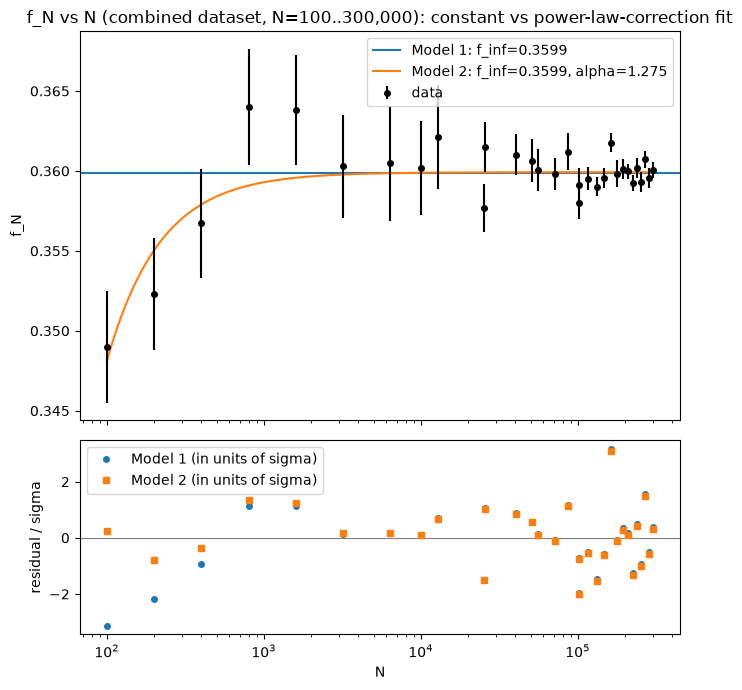

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True, height_ratios=[2, 1])

n_grid = np.geomspace(N.min(), N.max(), 300)

ax = axes[0]
ax.errorbar(N, f, yerr=se, fmt='o', color='black', label='data', zorder=3, markersize=4)
ax.axhline(f_inf_const, color='C0', label=f'Model 1: f_inf={f_inf_const:.4f}')
ax.plot(n_grid, model2(n_grid, *popt), color='C1',
        label=f'Model 2: f_inf={f_inf_m2:.4f}, alpha={alpha_m2:.3f}')
ax.set_xscale('log')
ax.set_ylabel('f_N')
ax.legend()
ax.set_title('f_N vs N (combined dataset, N=100..300,000): constant vs power-law-correction fit')

ax = axes[1]
ax.axhline(0, color='gray', linewidth=0.8)
ax.errorbar(N, model1_resid / se, fmt='o', color='C0', label='Model 1 (in units of sigma)', markersize=4)
ax.errorbar(N, model2_resid / se, fmt='s', color='C1', label='Model 2 (in units of sigma)', markersize=4)
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('residual / sigma')
ax.legend()

fig.tight_layout()
plt.show()

## Extended analysis: commensuration check, two-correction fit, log-periodic (conditional)

Following up on the apparent overshoot/oscillation seen in the combined-dataset
plot above. Order of investigation (per discussion 2026-09-13):

1. **(c) Commensuration check** (free -- no new simulation): group existing
   points by N mod 4, since the active-site window is 4 sites and the
   dynamics conserves dipole moment, so an N mod 4 effect is physically
   plausible.
2. **(a) Two competing corrections**: f(N) = f_inf + a/N^alpha + b/N^beta
   (5 parameters), which can produce a single overshoot rather than a flat
   monotonic approach.
3. **(b) Log-periodic** f(N) = f_inf + a/N^alpha * (1 + b*cos(omega*ln(N)+phi))
   (6 parameters) -- only fit if the residuals from (a) still show
   structure inconsistent with noise (chi^2 p-value check below), per the
   earlier caveat that fitting 3 more parameters to noise is not
   justified without better error bars.

N mod 4 counts: {0: 22, 2: 9}


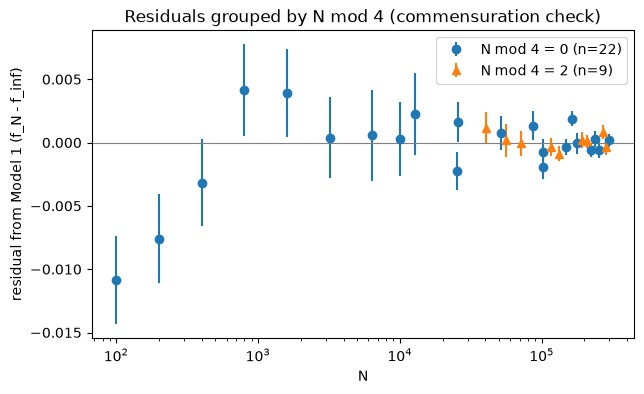


N mod 4 = 0: n=22, weighted mean residual = -0.00002 +- 0.00020
N mod 4 = 2: n= 9, weighted mean residual = +0.00003 +- 0.00023


In [6]:
# --- (c) Commensuration check: group by N mod 4 ---
residue = N.astype(int) % 4
print('N mod 4 counts:', {int(r): int(np.sum(residue == r)) for r in sorted(set(residue))})

fig, ax = plt.subplots(figsize=(7, 4))
markers = {0: 'o', 1: 's', 2: '^', 3: 'd'}
for r in sorted(set(residue)):
    mask = residue == r
    ax.errorbar(N[mask], model1_resid[mask], yerr=se[mask], fmt=markers[int(r)],
                label=f'N mod 4 = {int(r)} (n={mask.sum()})')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('residual from Model 1 (f_N - f_inf)')
ax.legend()
ax.set_title('Residuals grouped by N mod 4 (commensuration check)')
plt.show()

print()
for r in sorted(set(residue)):
    mask = residue == r
    w = 1.0 / se[mask]**2
    mean_resid = np.sum(model1_resid[mask] * w) / np.sum(w)
    err = np.sqrt(1.0 / np.sum(w))
    print(f'N mod 4 = {int(r)}: n={mask.sum():2d}, weighted mean residual = {mean_resid:+.5f} +- {err:.5f}')

In [7]:
# --- (a) Model 3: two competing corrections ---
def model3(n, f_inf, a, alpha, b, beta):
    return f_inf + a / n**alpha + b / n**beta

p0_3 = [f_inf_m2, a_m2, alpha_m2, -a_m2 * 0.3, alpha_m2 * 3]
popt3, pcov3 = curve_fit(model3, N, f, p0=p0_3, sigma=se, absolute_sigma=True, maxfev=100000)
f_inf_m3, a_m3, alpha_m3, b_m3, beta_m3 = popt3
perr3 = np.sqrt(np.diag(pcov3))

model3_pred = model3(N, *popt3)
model3_resid = f - model3_pred
model3_chi2 = chi_square(f, model3_pred, se)
model3_dof = n_points - 5
model3_red_chi2 = model3_chi2 / model3_dof

print('Model 3: f(N) = f_inf + a/N^alpha + b/N^beta')
print(f'  f_inf = {f_inf_m3:.5f} +- {perr3[0]:.5f}')
print(f'  a     = {a_m3:.5f} +- {perr3[1]:.5f}')
print(f'  alpha = {alpha_m3:.5f} +- {perr3[2]:.5f}')
print(f'  b     = {b_m3:.5f} +- {perr3[3]:.5f}')
print(f'  beta  = {beta_m3:.5f} +- {perr3[4]:.5f}')
print(f'  chi^2 = {model3_chi2:.3f}, dof = {model3_dof}, reduced chi^2 = {model3_red_chi2:.3f}')
print('  residuals (f_N - model3(N)):')
for n_i, r_i in zip(N, model3_resid):
    print(f'    N={int(n_i):6d}  residual={r_i:+.5f}')

Model 3: f(N) = f_inf + a/N^alpha + b/N^beta
  f_inf = 0.35992 +- 0.00015
  a     = -223197.49282 +- 489632752.84437
  alpha = 2.98567 +- 202.99037
  b     = 1150708.79040 +- 56149297.65810
  beta  = 3.35198 +- 276.73554
  chi^2 = 32.141, dof = 26, reduced chi^2 = 1.236
  residuals (f_N - model3(N)):
    N=   100  residual=-0.00001
    N=   200  residual=+0.00019
    N=   400  residual=-0.00159
    N=   800  residual=+0.00435
    N=  1600  residual=+0.00391
    N=  3200  residual=+0.00037
    N=  6400  residual=+0.00055
    N= 10000  residual=+0.00024
    N= 12800  residual=+0.00221
    N= 25264  residual=-0.00226
    N= 25600  residual=+0.00160
    N= 40526  residual=+0.00111
    N= 51200  residual=+0.00073
    N= 55790  residual=+0.00015
    N= 71054  residual=-0.00010
    N= 86316  residual=+0.00129
    N=101580  residual=-0.00078
    N=102400  residual=-0.00195
    N=116842  residual=-0.00040
    N=132106  residual=-0.00091
    N=147368  residual=-0.00039
    N=162632  residual=+0.

/var/folders/z_/tgnxpvj92jl2bzxg09ltsgxr0000gn/T/ipykernel_16560/1645434573.py:3: RuntimeWarning: divide by zero encountered in divide
  return f_inf + a / n**alpha + b / n**beta
/var/folders/z_/tgnxpvj92jl2bzxg09ltsgxr0000gn/T/ipykernel_16560/1645434573.py:3: RuntimeWarning: overflow encountered in power
  return f_inf + a / n**alpha + b / n**beta
/var/folders/z_/tgnxpvj92jl2bzxg09ltsgxr0000gn/T/ipykernel_16560/1645434573.py:3: RuntimeWarning: overflow encountered in divide
  return f_inf + a / n**alpha + b / n**beta


In [8]:
from scipy import stats

p_value_model3 = stats.chi2.sf(model3_chi2, model3_dof)
print(f'Model 3 chi^2 p-value = {p_value_model3:.3f} (dof={model3_dof})')

FIT_LOG_PERIODIC = p_value_model3 < 0.05
print(f'Residual structure inconsistent with noise at 5% level: {FIT_LOG_PERIODIC}')
if not FIT_LOG_PERIODIC:
    print('--> Not fitting the 6-parameter log-periodic model (b): the two-correction')
    print('    model already reduces residuals to something statistically consistent')
    print('    with noise, so a further 3-parameter oscillatory fit would be fitting')
    print('    noise, not signal, given the current error bars.')

Model 3 chi^2 p-value = 0.189 (dof=26)
Residual structure inconsistent with noise at 5% level: False
--> Not fitting the 6-parameter log-periodic model (b): the two-correction
    model already reduces residuals to something statistically consistent
    with noise, so a further 3-parameter oscillatory fit would be fitting
    noise, not signal, given the current error bars.


## Vanishing-form comparison (H1b, H1c) + model-free decay bound

Every model fit above (Model 1/2/3) has f_inf as a free parameter, i.e.
they all *assume* a nonzero floor. Finding f_inf != 0 from such models
does not by itself establish saturation. HYPOTHESES.md's H1 test plan
lists two *vanishing* candidates that have not been fit until now:

- **H1b:** f(N) = c * N^(-alpha)        (2 params)
- **H1c:** f(N) = c / ln(N)             (1 param)
  plus a less rigid variant c / (ln(N) + d)  (2 params)

Same weighted least squares / chi^2 convention as everything above, so
all models land in one comparison table.

Then, two things that do not assume any functional form:

- **local log-log slope** s = d ln(f) / d ln(N) over the last decade of
  data. If f_N -> 0 then s -> -alpha < 0; if f_N saturates then s -> 0.
- **upper bound on any asymptotic decay exponent**: no finite N range can
  prove saturation (a decay setting in beyond N=3e5 would be invisible),
  so the honest statement is a bound: if f_N ~ N^(-alpha) asymptotically,
  then alpha < alpha_max at 95% confidence.

In [9]:
# --- H1b: pure power law f(N) = c * N^(-alpha) ---
def model_h1b(n, c, alpha):
    return c * n**(-alpha)

popt_b, pcov_b = curve_fit(model_h1b, N, f, p0=[0.36, 0.001],
                           sigma=se, absolute_sigma=True, maxfev=100000)
c_b, alpha_b = popt_b
perr_b = np.sqrt(np.diag(pcov_b))

h1b_pred = model_h1b(N, *popt_b)
h1b_chi2 = chi_square(f, h1b_pred, se)
h1b_dof = n_points - 2
h1b_red_chi2 = h1b_chi2 / h1b_dof

print('H1b: f(N) = c * N^(-alpha)')
print(f'  c     = {c_b:.5f} +- {perr_b[0]:.5f}')
print(f'  alpha = {alpha_b:.6f} +- {perr_b[1]:.6f}')
print(f'  chi^2 = {h1b_chi2:.3f}, dof = {h1b_dof}, reduced chi^2 = {h1b_red_chi2:.3f}')
print(f'  alpha is {abs(alpha_b/perr_b[1]):.2f} sigma from zero')
print(f'  95% CI on alpha: [{alpha_b-1.96*perr_b[1]:+.6f}, {alpha_b+1.96*perr_b[1]:+.6f}]')

H1b: f(N) = c * N^(-alpha)
  c     = 0.35632 +- 0.00214
  alpha = -0.000829 +- 0.000500
  chi^2 = 44.389, dof = 29, reduced chi^2 = 1.531
  alpha is 1.66 sigma from zero
  95% CI on alpha: [-0.001809, +0.000151]


In [10]:
# --- H1c: f(N) = c / ln(N), and the less rigid c / (ln(N) + d) ---
def model_h1c(n, c):
    return c / np.log(n)

popt_c, pcov_c = curve_fit(model_h1c, N, f, p0=[3.0], sigma=se,
                           absolute_sigma=True, maxfev=100000)
c_c = popt_c[0]
perr_c = np.sqrt(np.diag(pcov_c))

h1c_pred = model_h1c(N, *popt_c)
h1c_chi2 = chi_square(f, h1c_pred, se)
h1c_dof = n_points - 1
h1c_red_chi2 = h1c_chi2 / h1c_dof

print('H1c: f(N) = c / ln(N)')
print(f'  c     = {c_c:.5f} +- {perr_c[0]:.5f}')
print(f'  chi^2 = {h1c_chi2:.3f}, dof = {h1c_dof}, reduced chi^2 = {h1c_red_chi2:.3f}')
print()

def model_h1c2(n, c, d):
    return c / (np.log(n) + d)

try:
    popt_c2, pcov_c2 = curve_fit(model_h1c2, N, f, p0=[10.0, 20.0], sigma=se,
                                 absolute_sigma=True, maxfev=200000)
    c_c2, d_c2 = popt_c2
    perr_c2 = np.sqrt(np.diag(pcov_c2))
    h1c2_pred = model_h1c2(N, *popt_c2)
    h1c2_chi2 = chi_square(f, h1c2_pred, se)
    h1c2_dof = n_points - 2
    h1c2_red_chi2 = h1c2_chi2 / h1c2_dof
    print('H1c variant: f(N) = c / (ln(N) + d)')
    print(f'  c     = {c_c2:.5f} +- {perr_c2[0]:.5f}')
    print(f'  d     = {d_c2:.5f} +- {perr_c2[1]:.5f}')
    print(f'  chi^2 = {h1c2_chi2:.3f}, dof = {h1c2_dof}, reduced chi^2 = {h1c2_red_chi2:.3f}')
    print(f'  (note: as d -> infinity this form tends to a constant c/d, i.e. it stops vanishing;')
    print(f'   implied plateau c/d = {c_c2/d_c2:.5f} over the fitted range)')
except RuntimeError as exc:
    h1c2_chi2 = h1c2_dof = h1c2_red_chi2 = float('nan')
    c_c2 = d_c2 = float('nan')
    print('H1c variant c/(ln N + d): fit did not converge --', exc)

H1c: f(N) = c / ln(N)
  c     = 4.21778 +- 0.00177
  chi^2 = 83288.634, dof = 30, reduced chi^2 = 2776.288

H1c variant: f(N) = c / (ln(N) + d)
  c     = 131319125.13927 +- 7981536380881.44238
  d     = 364896332.09476 +- 22178288797706.69531
  chi^2 = 47.157, dof = 29, reduced chi^2 = 1.626
  (note: as d -> infinity this form tends to a constant c/d, i.e. it stops vanishing;
   implied plateau c/d = 0.35988 over the fitted range)


In [11]:
# --- Unified comparison table, all models ---
rows = [
    ('M1 constant',   f'f_inf={f_inf_const:.5f}',                                    model1_chi2, model1_dof, model1_red_chi2),
    ('M2 f_inf+aN^-a',f'f_inf={f_inf_m2:.5f}, a={a_m2:.3f}, alpha={alpha_m2:.3f}',   model2_chi2, model2_dof, model2_red_chi2),
    ('M3 two-corr',   f'f_inf={f_inf_m3:.5f} (a,b,alpha,beta degenerate)',           model3_chi2, model3_dof, model3_red_chi2),
    ('H1b cN^-alpha', f'c={c_b:.5f}, alpha={alpha_b:.6f}',                           h1b_chi2,    h1b_dof,    h1b_red_chi2),
    ('H1c c/lnN',     f'c={c_c:.5f}',                                                h1c_chi2,    h1c_dof,    h1c_red_chi2),
    ('H1c c/(lnN+d)', f'c={c_c2:.3f}, d={d_c2:.3f}',                                 h1c2_chi2,   h1c2_dof,   h1c2_red_chi2),
]
print(f"{'model':<16} {'params':<52} {'chi2':>10} {'dof':>4} {'red chi2':>9}")
print('-'*95)
for name, params, c2, dof, rc2 in rows:
    print(f'{name:<16} {params:<52} {c2:10.3f} {dof:4d} {rc2:9.3f}')

model            params                                                     chi2  dof  red chi2
-----------------------------------------------------------------------------------------------
M1 constant      f_inf=0.35988                                            47.157   30     1.572
M2 f_inf+aN^-a   f_inf=0.35992, a=-4.184, alpha=1.275                     33.364   28     1.192
M3 two-corr      f_inf=0.35992 (a,b,alpha,beta degenerate)                32.141   26     1.236
H1b cN^-alpha    c=0.35632, alpha=-0.000829                               44.389   29     1.531
H1c c/lnN        c=4.21778                                             83288.634   30  2776.288
H1c c/(lnN+d)    c=131319125.139, d=364896332.095                         47.157   29     1.626


In [12]:
# --- Model-free local log-log slope + upper bound on any decay exponent ---
from scipy import stats as _stats

def local_slope(mask, label):
    x = np.log(N[mask])
    y = np.log(f[mask])
    sy = se[mask] / f[mask]          # propagated uncertainty on ln(f)
    coeffs, cov = np.polyfit(x, y, 1, w=1.0/sy, cov='unscaled')
    s, _ = coeffs
    s_err = np.sqrt(cov[0, 0])
    alpha_hat = -s
    alpha_upper95 = alpha_hat + 1.96 * s_err
    print(f'{label}  (n={mask.sum()} points, N={int(N[mask].min())}..{int(N[mask].max())})')
    print(f'  local slope s = d ln f / d ln N = {s:+.6f} +- {s_err:.6f}')
    print(f'  implied alpha = -s = {alpha_hat:+.6f} +- {s_err:.6f}   ({abs(alpha_hat/s_err):.2f} sigma from zero)')
    print(f'  95% upper bound on a decay exponent: alpha < {alpha_upper95:.6f}')
    if alpha_upper95 > 0:
        decade_drop = 1 - 10**(-alpha_upper95)
        print(f'  -> at that bound, f would fall by at most {decade_drop*100:.3f}% per decade of N')
    print()
    return s, s_err

print('Model-free local log-log slope (no functional form assumed)')
print('='*70)
local_slope(N >= 3e4, 'Last decade  N >= 3e4:')
local_slope(N >= 1e4, 'N >= 1e4:')
local_slope(N >= 1e3, 'N >= 1e3:')

Model-free local log-log slope (no functional form assumed)
Last decade  N >= 3e4:  (n=20 points, N=40526..300000)
  local slope s = d ln f / d ln N = +0.000081 +- 0.000946
  implied alpha = -s = -0.000081 +- 0.000946   (0.09 sigma from zero)
  95% upper bound on a decay exponent: alpha < 0.001774
  -> at that bound, f would fall by at most 0.408% per decade of N

N >= 1e4:  (n=24 points, N=10000..300000)
  local slope s = d ln f / d ln N = +0.000052 +- 0.000758
  implied alpha = -s = -0.000052 +- 0.000758   (0.07 sigma from zero)
  95% upper bound on a decay exponent: alpha < 0.001433
  -> at that bound, f would fall by at most 0.329% per decade of N

N >= 1e3:  (n=27 points, N=1600..300000)
  local slope s = d ln f / d ln N = -0.000249 +- 0.000661
  implied alpha = -s = +0.000249 +- 0.000661   (0.38 sigma from zero)
  95% upper bound on a decay exponent: alpha < 0.001544
  -> at that bound, f would fall by at most 0.355% per decade of N



(np.float64(-0.00024918914467672923), np.float64(0.0006608153980204437))

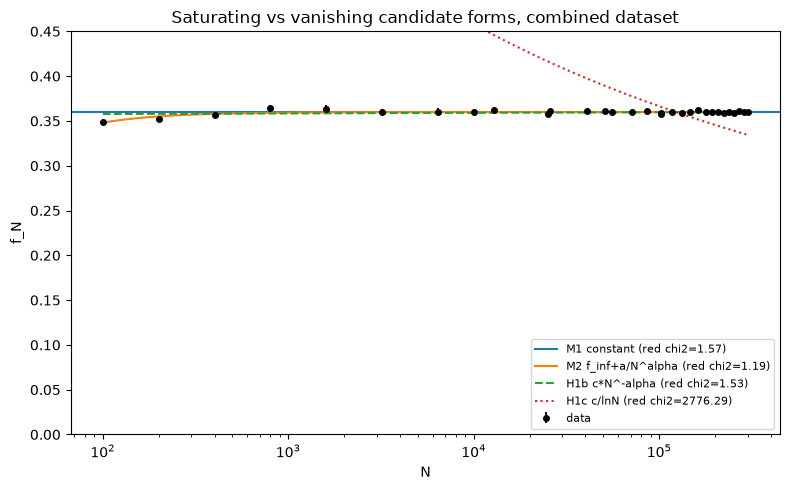

In [13]:
# --- All candidate models overlaid on the data ---
fig, ax = plt.subplots(figsize=(8, 5))
n_grid = np.geomspace(N.min(), N.max(), 400)

ax.errorbar(N, f, yerr=se, fmt='o', color='black', label='data', zorder=5, markersize=4)
ax.axhline(f_inf_const, color='C0', label=f'M1 constant (red chi2={model1_red_chi2:.2f})')
ax.plot(n_grid, model2(n_grid, *popt), color='C1',
        label=f'M2 f_inf+a/N^alpha (red chi2={model2_red_chi2:.2f})')
ax.plot(n_grid, model_h1b(n_grid, *popt_b), color='C2', linestyle='--',
        label=f'H1b c*N^-alpha (red chi2={h1b_red_chi2:.2f})')
ax.plot(n_grid, model_h1c(n_grid, *popt_c), color='C3', linestyle=':',
        label=f'H1c c/lnN (red chi2={h1c_red_chi2:.2f})')
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('f_N')
ax.set_ylim(0.0, 0.45)
ax.legend(loc='lower right', fontsize=8)
ax.set_title('Saturating vs vanishing candidate forms, combined dataset')
fig.tight_layout()
plt.show()